In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('AB_NYC_2019.csv')

In [38]:
#Data cleaning
#Vacios, duplicados, erróneos, conflictivos
df_copy = df
df_copy.shape

(48895, 16)

In [39]:
df_copy.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [40]:
# Nota extra: media, mediana y moda
df_sin_vacios = df_copy[df_copy.notnull().all(axis=1)]
df_sin_vacios.shape

(38821, 16)

In [41]:
# Promedio, media, moda y KNN
promedio = df_copy['reviews_per_month'].mean()
df_copy['reviews_per_month'] = df_copy['reviews_per_month'].fillna(promedio) # fillna rellena los vacios

mediana = df_copy['reviews_per_month'].median()
df_copy['reviews_per_month'] = df_copy['reviews_per_month'].fillna(mediana)

In [42]:
moda = df_copy['last_review'].mode()[0]
df_copy['last_review'] = df_copy['last_review'].fillna(moda)

In [43]:
df_copy.isnull().sum()

id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

In [44]:
# Lennar vacios (Imputar) con KNN
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=4)
df_copy[['price', 'minimum_nights']] = imputer.fit_transform(df_copy[['price', 'minimum_nights']])

In [45]:
# Duplicados
df_copy.duplicated().sum()

np.int64(0)

In [46]:
# Atributo inplace = True, los cambios se efectuan directamente sobre el dataframe
# df_copy = df_copy.drop_duplicates()
df_copy.drop_duplicates(inplace = True)

In [47]:
rivers = pd.read_csv('rivers.csv')
rivers

,rownames,dat
0,1,735
1,2,320
2,3,325
3,4,392
4,5,524
...,...,...
136,137,720
137,138,270
138,139,430
139,140,671


<Axes: ylabel='Frequency'>

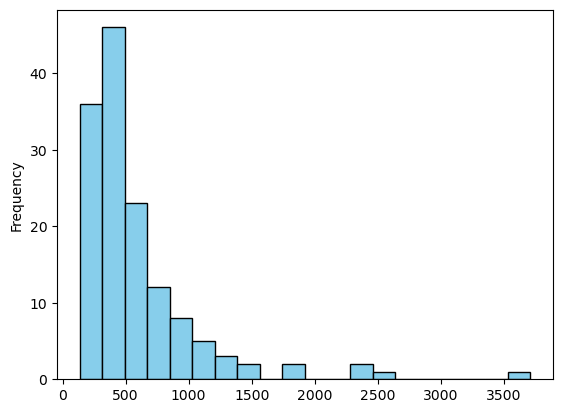

In [48]:
rivers['dat'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')

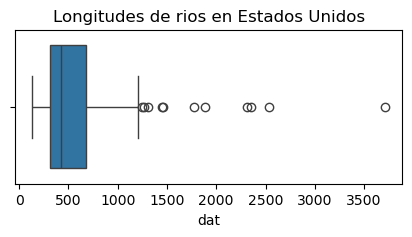

In [49]:
plt.figure(figsize=(5, 2))  # Crea grafica con ese tamaño
sns.boxplot(x=rivers['dat']) # Crea la grafica de caja o de bigote
plt.title('Longitudes de rios en Estados Unidos')
plt.show()

In [50]:
Q1 = rivers['dat'].quantile(0.25)
Q1

np.float64(310.0)

In [51]:
Q3 = rivers['dat'].quantile(0.75)
Q3

np.float64(680.0)

In [52]:
low_limit = Q1 - 1.5 * (Q3 - Q1)
high_limit = Q3 + 1.5 * (Q3 - Q1)
print(low_limit, high_limit)

-245.0 1235.0


In [53]:
rivers_limpio = rivers[(rivers['dat']>=low_limit) & (rivers['dat']<=high_limit)]
rivers_limpio.shape

(130, 2)

In [54]:
# Usando el dataset AB_NYC_2019.csv identifica cuantos valores atipicos existen en price 
# y crea un dataframe de precios sin valores atipicos
ab_nyc = pd.read_csv('AB_NYC_2019.csv')
real = ab_nyc.shape[0]
Q1 = ab_nyc['price'].quantile(0.25)
Q3 = ab_nyc['price'].quantile(0.75)
low_limit = Q1 - 1.5 * (Q3 - Q1)
high_limit = Q3 + 1.5 * (Q3 - Q1)
ab_nyc_limpio = ab_nyc[(ab_nyc['price']>=low_limit) & (ab_nyc['price']<=high_limit)]
limpio = ab_nyc_limpio.shape[0]  # Shape regresa cantidad de registros y luego las columnas
print("Valores atipicos: ", real - limpio)

Valores atipicos:  2972


In [55]:
# Generalización
import numpy as np 
import pandas as pd

ab_nyc['costo'] = np.where(ab_nyc['price'] >= 600, 'caro', 'barato')
ab_nyc

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,costo
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,barato
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,barato
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,barato
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,barato
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,barato
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,barato
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,barato
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,barato
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,barato


In [56]:
# Definimos los limites de los rangos (desde 0, hasta 200, hasta 600, y el infinito para los mas caros)
limites = [0, 200, 600, float('inf')]
etiquetas = ['barato', 'moderado', 'caro']

ab_nyc['costo_cut'] = pd.cut(ab_nyc['price'], bins=limites, labels=etiquetas)
ab_nyc

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,costo,costo_cut
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,barato,barato
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,barato,moderado
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,barato,barato
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,barato,barato
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,barato,barato
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,barato,barato
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,barato,barato
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,barato,barato
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,barato,barato


In [57]:
# Reescalamiento y normalizacion
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalización
scaler_std = StandardScaler()
ab_nyc['price_std'] = scaler_std.fit_transform(ab_nyc[['price']])
# Hace reescalamiento pero considerando la desviacion estandar

#Reescalamiento
scaler_minmax = MinMaxScaler()
ab_nyc['price_minmax'] = scaler_minmax.fit_transform(ab_nyc[['price']])
ab_nyc
# Reescalamiento cambia la escala de valores de una columna considerando el maximo y el minimo, donde el 1 es el maximo y el 0 es el minimo

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,costo,costo_cut,price_std,price_minmax
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,barato,barato,-0.015493,0.0149
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,barato,moderado,0.300974,0.0225
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,barato,barato,-0.011329,0.0150
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,barato,barato,-0.265335,0.0089
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,barato,barato,-0.302811,0.0080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,barato,barato,-0.344452,0.0070
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,barato,barato,-0.469373,0.0040
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,barato,barato,-0.157070,0.0115
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,barato,barato,-0.406912,0.0055


In [58]:
# Smoothing
ab_nyc['availability_smooth'] = ab_nyc['availability_365'].rolling(window=10).mean()

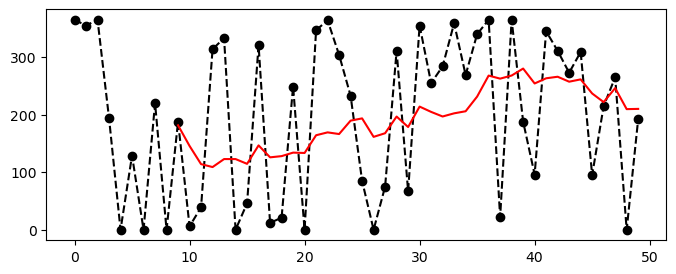

In [61]:
plt.figure(figsize=(8, 3))
plt.plot(ab_nyc.head(50).index, ab_nyc.head(50)['availability_365'], color='black', marker='o', linestyle='--')
plt.plot(ab_nyc.head(50).index, ab_nyc.head(50)['availability_smooth'], color='red')
plt.show()